In [2]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support
import joblib

# 1. Load data
df = pd.read_csv('../DATA/Processed/pulseops_enriched.csv')

# 2. Pick features — exclude failure-type cols (leaky), exclude IDs
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'temp_diff', 'low_temp_diff_flag', 'high_torque_flag', 'high_tool_wear_flag']
target = 'Machine failure'

# 3. Encode categorical (Type: H/L/M) → dummy cols
X = pd.get_dummies(df[feature_cols], columns=['Type'], drop_first=True)
y = df[target]

# 4. Split — stratify keeps failure ratio same in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Model — class_weight balanced compensates for 3.39% failure rate
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

# 6. Predict
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # failure probability

# 7. Metrics
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
auc = roc_auc_score(y_test, y_proba)
print(f"Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  ROC-AUC: {auc:.3f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# 8. Feature importance
fi = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}) \
       .sort_values('importance', ascending=False)
print(fi)

# 9. Score full dataset — for Power BI risk page
df['ml_risk_score'] = rf.predict_proba(X)[:, 1]
df['ml_predicted_failure'] = rf.predict(X)
df['ml_risk_tier'] = pd.cut(df['ml_risk_score'], bins=[-0.01,0.2,0.5,0.8,1.01],
                              labels=['Low','Medium','High','Critical'])

# 10. Save
df.to_csv('../DATA/Processed/pulseops_enriched_with_ml.csv', index=False)
joblib.dump(rf, '../DATA/Synthetic/pulseops_rf_model.joblib')

Precision: 0.609  Recall: 0.824  F1: 0.700  ROC-AUC: 0.980
[[1896   36]
 [  12   56]]
              precision    recall  f1-score   support

           0      0.994     0.981     0.988      1932
           1      0.609     0.824     0.700        68

    accuracy                          0.976      2000
   macro avg      0.801     0.902     0.844      2000
weighted avg      0.981     0.976     0.978      2000

                    feature  importance
3               Torque [Nm]    0.289353
2    Rotational speed [rpm]    0.245352
4           Tool wear [min]    0.179974
7          high_torque_flag    0.070321
5                 temp_diff    0.051171
6        low_temp_diff_flag    0.045366
8       high_tool_wear_flag    0.042776
0       Air temperature [K]    0.036250
1   Process temperature [K]    0.027096
9                    Type_L    0.006683
10                   Type_M    0.005658


['../DATA/Synthetic/pulseops_rf_model.joblib']

In [3]:
# score EVERY row (not just test set) — full dataset
df['ml_risk_score'] = rf.predict_proba(X)[:, 1]
df['ml_predicted_failure'] = rf.predict(X)
df['ml_risk_tier'] = pd.cut(df['ml_risk_score'], bins=[-0.01,0.2,0.5,0.8,1.01],
                              labels=['Low','Medium','High','Critical'])

print(df['ml_risk_tier'].value_counts())
df.to_csv('pulseops_enriched_with_ml.csv', index=False)

ml_risk_tier
Low         8988
Medium       553
Critical     299
High         160
Name: count, dtype: int64


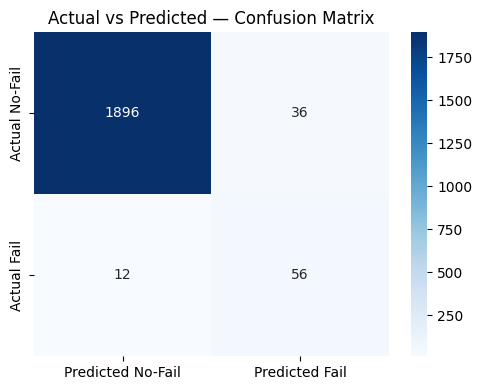

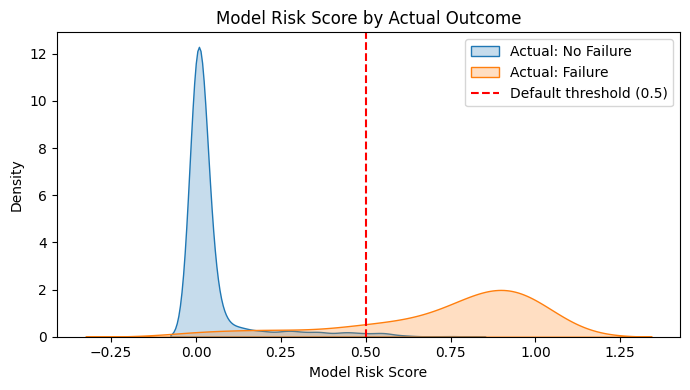

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Confusion matrix heatmap — actual vs predicted, visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No-Fail','Predicted Fail'],
            yticklabels=['Actual No-Fail','Actual Fail'])
plt.title('Actual vs Predicted — Confusion Matrix')
plt.tight_layout()
plt.savefig('../Assets/confusion_matrix.png', dpi=150)
plt.show()

# 2. Risk score distribution split by ACTUAL outcome — shows if model separates classes
plt.figure(figsize=(7,4))
sns.kdeplot(y_proba[y_test==0], label='Actual: No Failure', fill=True)
sns.kdeplot(y_proba[y_test==1], label='Actual: Failure', fill=True)
plt.axvline(0.5, color='red', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Model Risk Score')
plt.title('Model Risk Score by Actual Outcome')
plt.legend()
plt.tight_layout()
plt.savefig('../Assets/risk_score_distribution.png', dpi=150)
plt.show()